# 2. Data Understanding (EDA)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style='whitegrid')

## 2.1 Load Dataset

In [18]:
df = pd.read_csv('../Datasets/hypertension_dataset.csv')
display(df.head())
print('\nInfo Dataset:')
df.info()
print('\nStatistik Deskriptif:')
display(df.describe(include='all'))

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No



Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   str    
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   str    
 7   Family_History    1985 non-null   str    
 8   Exercise_Level    1985 non-null   str    
 9   Smoking_Status    1985 non-null   str    
 10  Has_Hypertension  1985 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 170.7 KB

Statistik Deskriptif:


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
count,1985.000000,1985.000000,1985.000000,1985,1985.000000,1985.000000,1186,1985,1985,1985,1985
unique,NaN,NaN,NaN,3,NaN,NaN,4,2,3,2,2
top,NaN,NaN,NaN,Normal,NaN,NaN,Beta Blocker,No,Low,Non-Smoker,Yes
freq,NaN,NaN,NaN,796,NaN,NaN,412,1000,936,1417,1032
mean,50.341058,8.531688,4.979345,NaN,6.452242,26.015315,NaN,NaN,NaN,NaN,NaN
std,19.442042,1.994907,3.142303,NaN,1.542207,4.512857,NaN,NaN,NaN,NaN,NaN
min,18.000000,2.500000,0.000000,NaN,1.500000,11.900000,NaN,NaN,NaN,NaN,NaN
25%,34.000000,7.200000,2.000000,NaN,5.400000,23.000000,NaN,NaN,NaN,NaN,NaN
50%,50.000000,8.500000,5.000000,NaN,6.500000,25.900000,NaN,NaN,NaN,NaN,NaN
75%,67.000000,9.900000,8.000000,NaN,7.500000,29.100000,NaN,NaN,NaN,NaN,NaN


## 2.2 Distribusi Variabel Target (Has_Hypertension)

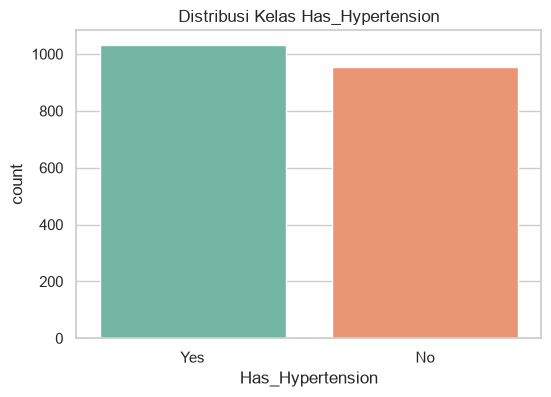

Jumlah per kelas:
Has_Hypertension
Yes    1032
No      953
Name: count, dtype: int64

Persentase per kelas:
Has_Hypertension
Yes    51.99
No     48.01
Name: proportion, dtype: float64

Rasio imbalance: 1.08 : 1


In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Has_Hypertension', palette='Set2')
plt.title('Distribusi Kelas Has_Hypertension')
plt.show()

target_counts = df['Has_Hypertension'].value_counts()
target_pct = df['Has_Hypertension'].value_counts(normalize=True) * 100

print("Jumlah per kelas:")
print(target_counts)
print("\nPersentase per kelas:")
print(target_pct.round(2))

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nRasio imbalance: {imbalance_ratio:.2f} : 1")

## 2.3 Analisis Numerik: Salt Intake vs Hypertension

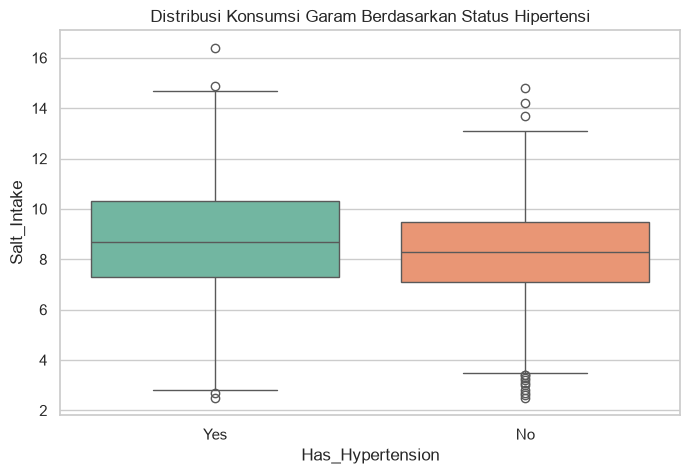

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Has_Hypertension', y='Salt_Intake', palette='Set2')
plt.title('Distribusi Konsumsi Garam Berdasarkan Status Hipertensi')
plt.show()

## 2.4 Cek Outlier

In [21]:
num_cols_check = df.select_dtypes(include=['number']).columns.tolist()

print("=== Hasil Deteksi Outlier ===\n")
for col in num_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = df[(df[col] < batas_bawah) | (df[col] > batas_atas)]
    pct = len(outlier) / len(df) * 100

    print(f"{col}:")
    print(f"  Batas bawah : {batas_bawah:.2f}")
    print(f"  Batas atas  : {batas_atas:.2f}")
    print(f"  Jumlah outlier: {len(outlier)} ({pct:.2f}% dari total data)\n")

=== Hasil Deteksi Outlier ===

Age:
  Batas bawah : -15.50
  Batas atas  : 116.50
  Jumlah outlier: 0 (0.00% dari total data)

Salt_Intake:
  Batas bawah : 3.15
  Batas atas  : 13.95
  Jumlah outlier: 17 (0.86% dari total data)

Stress_Score:
  Batas bawah : -7.00
  Batas atas  : 17.00
  Jumlah outlier: 0 (0.00% dari total data)

Sleep_Duration:
  Batas bawah : 2.25
  Batas atas  : 10.65
  Jumlah outlier: 12 (0.60% dari total data)

BMI:
  Batas bawah : 13.85
  Batas atas  : 38.25
  Jumlah outlier: 16 (0.81% dari total data)



## 2.5 Korelasi Antar Variabel Numerik

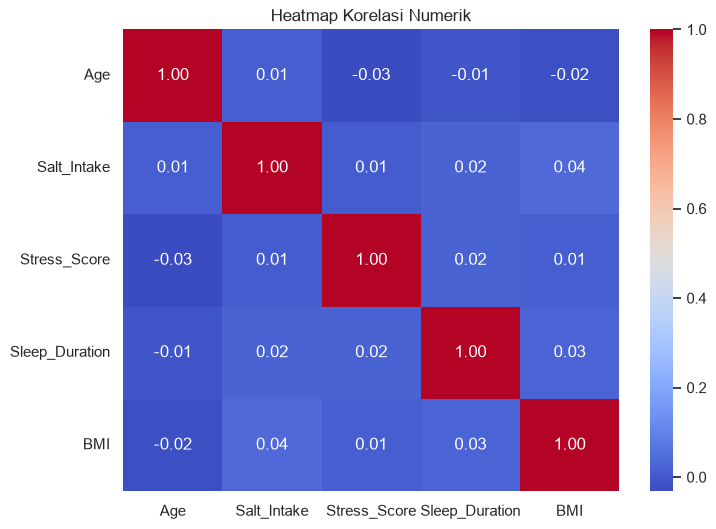

In [22]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Numerik')
plt.show()

## 2.6 Distribusi Fitur Kategorikal

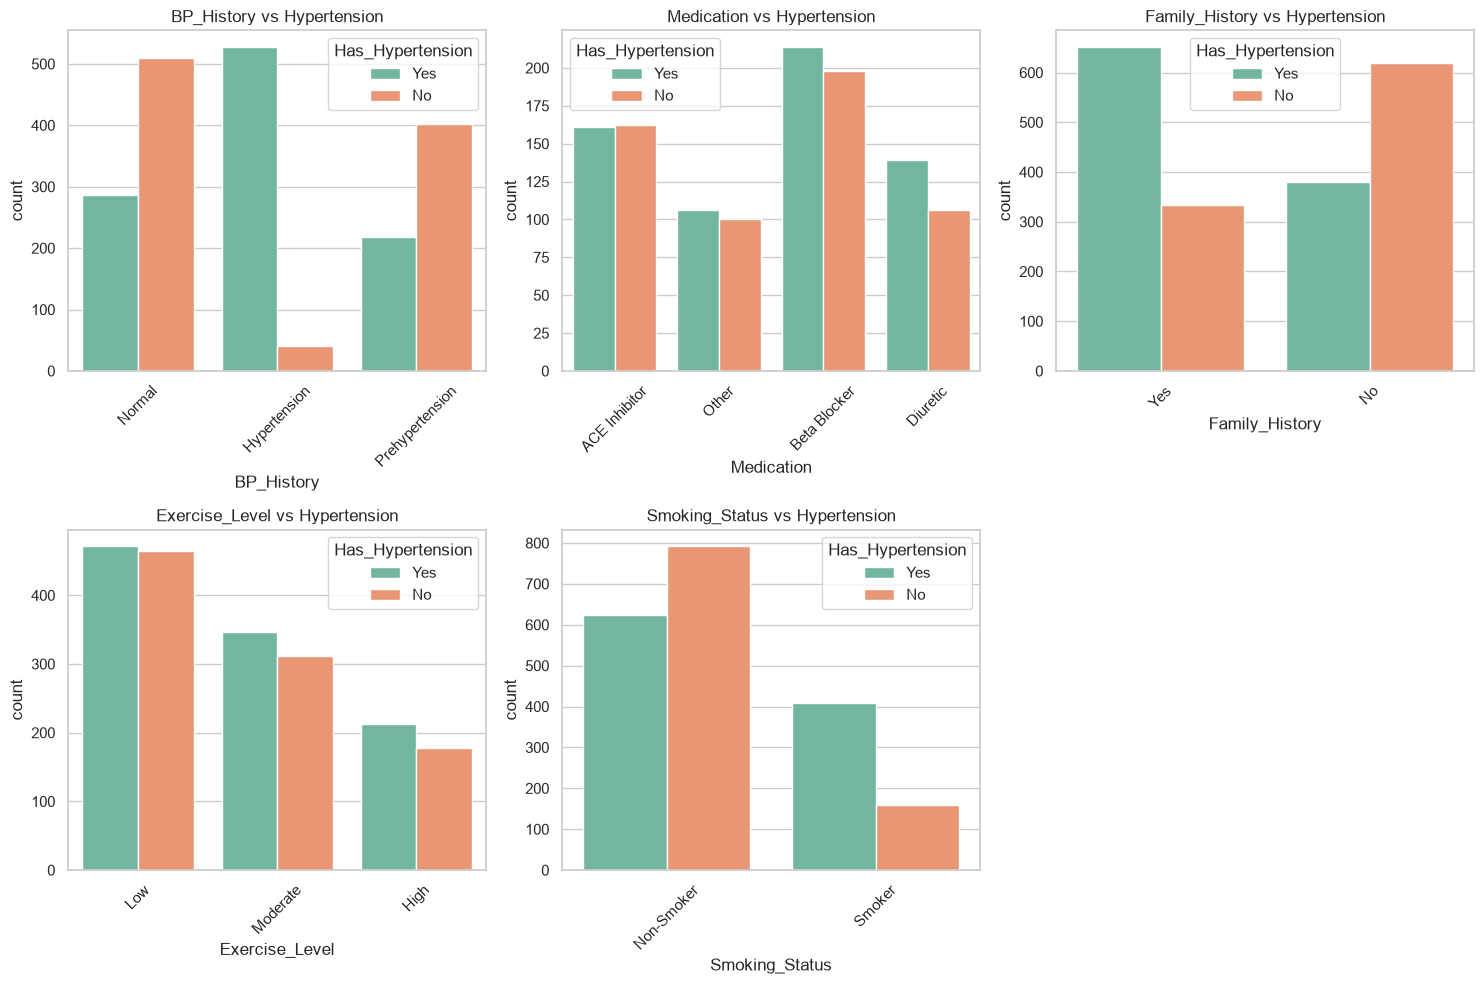

In [23]:
categorical_cols = df.select_dtypes(include=['object']).columns.drop('Has_Hypertension')
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, hue='Has_Hypertension', palette='Set2')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Hypertension')
plt.tight_layout()
plt.show()

## 2.7 Tabel Acuan Indikasi Hipertensi

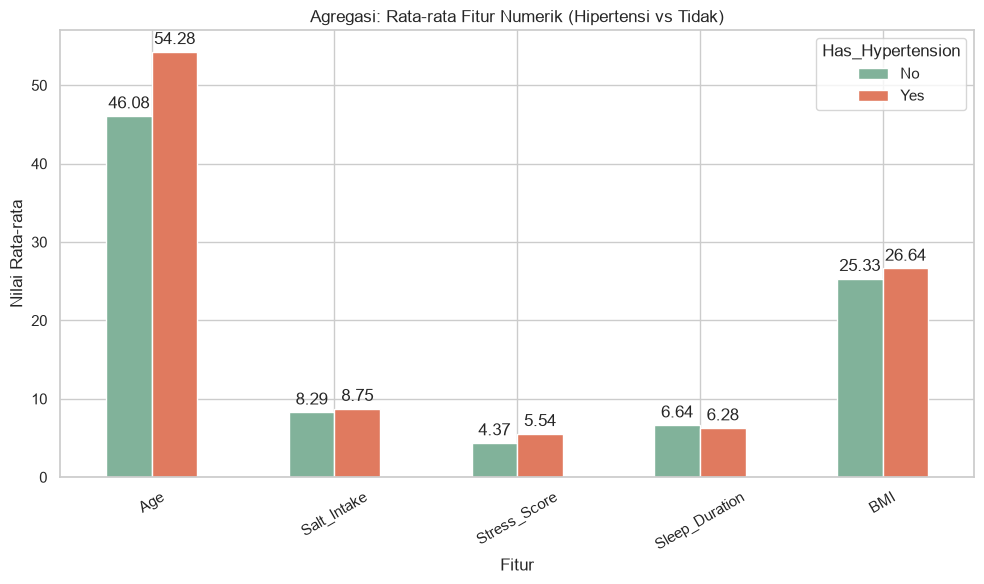


Tabel Acuan Indikasi Hipertensi (Semua Fitur/Kategori):


,Label,Nilai (%),Status,Kekuatan Indikasi
0,BP_History: Hypertension,92.794376,Terindikasi,42.8
1,Stress_Score > 4.96,23.714772,Terindikasi,23.7
2,Smoking_Status: Smoker,71.830986,Terindikasi,21.8
3,Age > 50.18,16.334692,Terindikasi,16.3
4,Family_History: Yes,66.192893,Terindikasi,16.2
5,BP_History: Prehypertension,35.161290,Tidak Terindikasi,14.8
6,BP_History: Normal,35.929648,Tidak Terindikasi,14.1
7,Family_History: No,38.000000,Tidak Terindikasi,12.0
8,Medication: Diuretic,56.734694,Terindikasi,6.7
9,Smoking_Status: Non-Smoker,44.036697,Tidak Terindikasi,6.0


In [24]:
# ---------- PLOT Agregasi Rata-rata Fitur Numerik ----------
agg_numeric = df.groupby('Has_Hypertension')[numeric_cols].mean().T

fig, ax = plt.subplots(figsize=(10, 6))
agg_numeric.plot(kind='bar', ax=ax, color=['#81b29a', '#e07a5f'])
ax.set_title('Agregasi: Rata-rata Fitur Numerik (Hipertensi vs Tidak)')
ax.set_ylabel('Nilai Rata-rata')
ax.set_xlabel('Fitur')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Has_Hypertension')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

# ---------- TABEL ACUAN GABUNGAN ----------
acuan_rows = []

for col in categorical_cols:
    crosstab_pct = pd.crosstab(df[col], df['Has_Hypertension'], normalize='index') * 100
    for kategori in crosstab_pct.index:
        pct_yes = crosstab_pct.loc[kategori, 'Yes']
        status = "Terindikasi" if pct_yes > 50 else "Tidak Terindikasi"
        selisih = abs(pct_yes - 50)
        acuan_rows.append({
            'Label': f"{col}: {kategori}",
            'Nilai (%)': pct_yes,
            'Status': status,
            'Kekuatan Indikasi': round(selisih, 1)
        })

for col in numeric_cols:
    mean_yes = df[df['Has_Hypertension'] == 'Yes'][col].mean()
    mean_no = df[df['Has_Hypertension'] == 'No'][col].mean()
    threshold = (mean_yes + mean_no) / 2
    arah = ">" if mean_yes > mean_no else "<"
    selisih_relatif = abs(mean_yes - mean_no) / ((mean_yes + mean_no) / 2) * 100
    acuan_rows.append({
        'Label': f"{col} {arah} {threshold:.2f}",
        'Nilai (%)': selisih_relatif,
        'Status': "Terindikasi",
        'Kekuatan Indikasi': round(selisih_relatif, 1)
    })

df_acuan = pd.DataFrame(acuan_rows).sort_values('Kekuatan Indikasi', ascending=False).reset_index(drop=True)

print("\nTabel Acuan Indikasi Hipertensi (Semua Fitur/Kategori):")
display(df_acuan)